In [305]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [306]:
df = pd.DataFrame()

In [307]:
df['X1'] = [1, 2, 3, 4, 5, 6, 6, 7, 9, 9]
df['X2'] = [5, 3, 6, 8, 1, 9, 5, 8, 9, 2]
df['Label'] = [1, 1, 0, 1, 0, 1, 0, 1, 0, 0]

In [308]:
df

,X1,X2,Label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


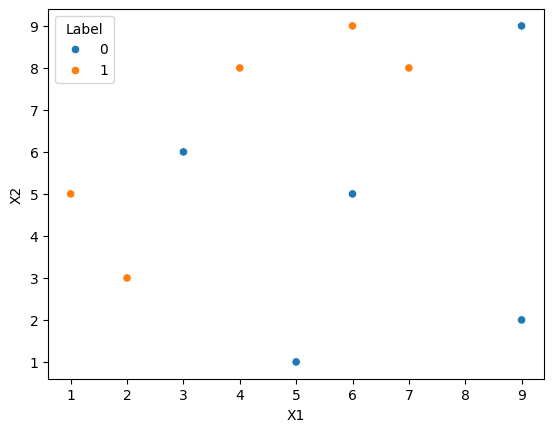

In [309]:
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['Label'])
plt.show()

In [310]:
# step 1 - Add weights
df['weights'] = 1/df.shape[0]

In [311]:
df

,X1,X2,Label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [312]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [313]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [314]:
# step 2 - Train 1st model
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

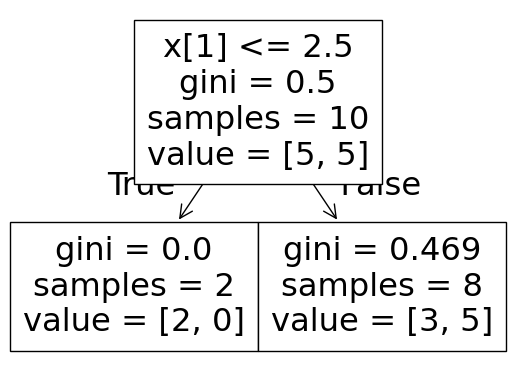

In [315]:
plot_tree(dt1)

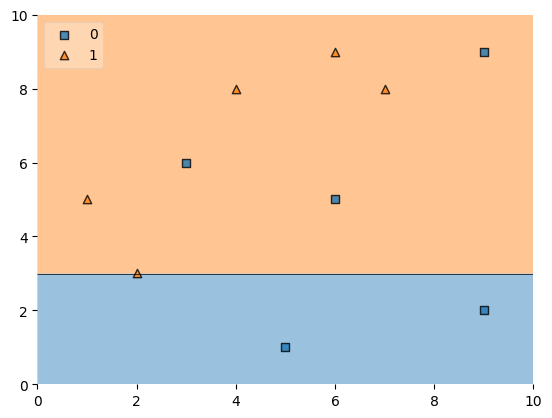

In [316]:
plot_decision_regions(X,y, dt1, legend=2)
plt.show()

In [317]:
df['y_pred'] = dt1.predict(X)

In [318]:
df

,X1,X2,Label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [319]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error))

In [320]:
# step 3 - calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [321]:
# step 4 - update weights
def update_row_weights(row, alpha=0.423):
    if row['Label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [322]:
df['updated_weights'] = df.apply(update_row_weights, axis=1)

In [323]:
df

,X1,X2,Label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [324]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [325]:
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [326]:
df

,X1,X2,Label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [327]:
df['normalized_weights'].sum()

np.float64(1.0)

In [328]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])

In [329]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [330]:
df[['X1','X2', 'weights', 'y_pred', 'updated_weights', 'cumsum_lower', 'cumsum_upper']]

,X1,X2,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,0.1,1,0.065508,0.000000,0.071475
1,2,3,0.1,1,0.065508,0.071475,0.142950
2,3,6,0.1,1,0.152653,0.142950,0.309508
3,4,8,0.1,1,0.065508,0.309508,0.380983
4,5,1,0.1,0,0.065508,0.380983,0.452458
5,6,9,0.1,1,0.065508,0.452458,0.523933
6,6,5,0.1,1,0.152653,0.523933,0.690492
7,7,8,0.1,1,0.065508,0.690492,0.761967
8,9,9,0.1,1,0.152653,0.761967,0.928525
9,9,2,0.1,0,0.065508,0.928525,1.000000


In [331]:
# Upsampling 
def create_new_df(df):
    indices = []
    for i in range(df.shape[0]):
        a = np.random.random()
        for index, row in df.iterrows():
            if row['cumsum_upper'] > a and a > row['cumsum_lower']:
                indices.append(index)
    return indices

In [332]:
index_values = create_new_df(df)
index_values

[3, 5, 0, 8, 1, 6, 2, 0, 6, 8]

In [333]:
second_df = df.iloc[index_values, [0,1,2,3]]
second_df

,X1,X2,Label,weights
3,4,8,1,0.1
5,6,9,1,0.1
0,1,5,1,0.1
8,9,9,0,0.1
1,2,3,1,0.1
6,6,5,0,0.1
2,3,6,0,0.1
0,1,5,1,0.1
6,6,5,0,0.1
8,9,9,0,0.1


In [334]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [335]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [336]:
dt2.fit(X, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.625, 0.5, '  False')]

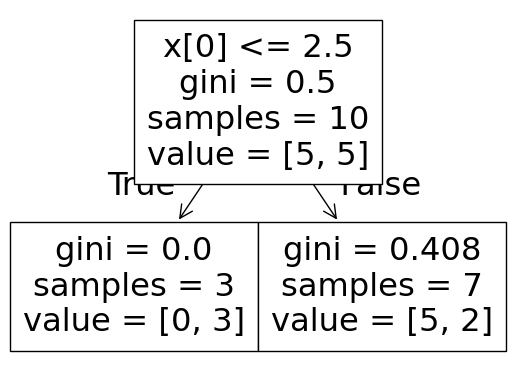

In [337]:
plot_tree(dt2)

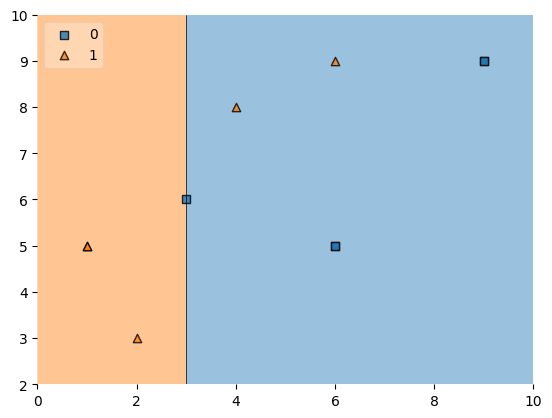

In [338]:
plot_decision_regions(X,y,dt2, legend=2)
plt.show()

In [342]:
second_df['y_pred'] = dt2.predict(X)
second_df

,X1,X2,Label,weights,y_pred
3,4,8,1,0.1,0
5,6,9,1,0.1,0
0,1,5,1,0.1,1
8,9,9,0,0.1,0
1,2,3,1,0.1,1
6,6,5,0,0.1,0
2,3,6,0,0.1,0
0,1,5,1,0.1,1
6,6,5,0,0.1,0
8,9,9,0,0.1,0


In [383]:
# calculate alpha of model 2
alpha2 = calculate_model_weight(0.2)

In [347]:
def update_row_weights(row, alpha=0.69):
    if row['Label'] == row['y_pred']:
        # reduce focus from correctly classified points
        return row['weights']*np.exp(-alpha)
    else: # increase focus on correclty classified points
        return row['weights']*np.exp(alpha)

In [349]:
second_df['updated_weights'] = second_df.apply(update_row_weights, axis=1)

In [350]:
second_df

,X1,X2,Label,weights,y_pred,updated_weights
3,4,8,1,0.1,0,0.199372
5,6,9,1,0.1,0,0.199372
0,1,5,1,0.1,1,0.050158
8,9,9,0,0.1,0,0.050158
1,2,3,1,0.1,1,0.050158
6,6,5,0,0.1,0,0.050158
2,3,6,0,0.1,0,0.050158
0,1,5,1,0.1,1,0.050158
6,6,5,0,0.1,0,0.050158
8,9,9,0,0.1,0,0.050158


In [351]:
second_df['updated_weights'].sum()

np.float64(0.800003961901461)

In [353]:
second_df['normalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [354]:
second_df['normalized_weights'].sum()

np.float64(1.0)

In [364]:
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_weights'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized_weights']

In [366]:
second_df[['X1', 'X2', 'Label', 'weights', 'y_pred', 'normalized_weights', 'cumsum_lower', 'cumsum_upper']]

,X1,X2,Label,weights,y_pred,normalized_weights,cumsum_lower,cumsum_upper
3,4,8,1,0.1,0,0.249213,0.000000,0.249213
5,6,9,1,0.1,0,0.249213,0.249213,0.498426
0,1,5,1,0.1,1,0.062697,0.498426,0.561123
8,9,9,0,0.1,0,0.062697,0.561123,0.623820
1,2,3,1,0.1,1,0.062697,0.623820,0.686517
6,6,5,0,0.1,0,0.062697,0.686517,0.749213
2,3,6,0,0.1,0,0.062697,0.749213,0.811910
0,1,5,1,0.1,1,0.062697,0.811910,0.874607
6,6,5,0,0.1,0,0.062697,0.874607,0.937303
8,9,9,0,0.1,0,0.062697,0.937303,1.000000


In [368]:
index_values = create_new_df(second_df)
index_values

[1, 6, 3, 5, 3, 0, 6, 0, 3, 5]

In [370]:
third_df = df.iloc[index_values, [0,1,2,3]]
third_df

,X1,X2,Label,weights
1,2,3,1,0.1
6,6,5,0,0.1
3,4,8,1,0.1
5,6,9,1,0.1
3,4,8,1,0.1
0,1,5,1,0.1
6,6,5,0,0.1
0,1,5,1,0.1
3,4,8,1,0.1
5,6,9,1,0.1


In [372]:
X = third_df.iloc[:,0:2].values
y = third_df.iloc[:,2].values

[Text(0.5, 0.75, 'x[0] <= 5.0\ngini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.625, 0.5, '  False')]

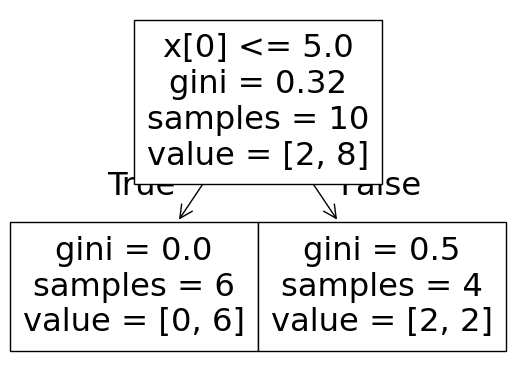

In [374]:
dt3 = DecisionTreeClassifier(max_depth=1)
dt3.fit(X,y)
plot_tree(dt3)

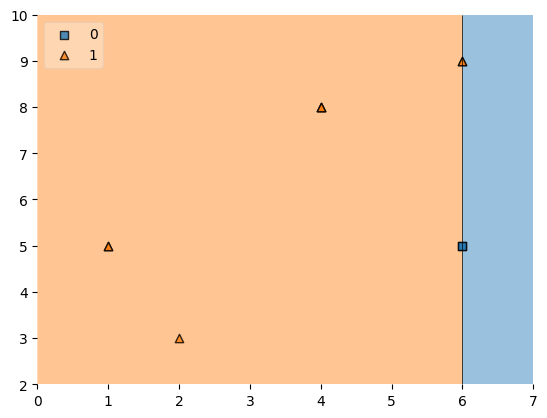

In [377]:
plot_decision_regions(X,y,dt3, legend=2)
plt.show()

In [380]:
third_df['y_pred'] = dt3.predict(X)
third_df

,X1,X2,Label,weights,y_pred
1,2,3,1,0.1,1
6,6,5,0,0.1,0
3,4,8,1,0.1,1
5,6,9,1,0.1,0
3,4,8,1,0.1,1
0,1,5,1,0.1,1
6,6,5,0,0.1,0
0,1,5,1,0.1,1
3,4,8,1,0.1,1
5,6,9,1,0.1,0


In [382]:
alpha3 = calculate_model_weight(0.1)

In [384]:
print(alpha1, alpha2, alpha3)

0.42364893019360184 0.6931471805599453 1.0986122886681098


#### Predictions from all the `Decision Stumps`

In [403]:
query1 = np.array([2,3]).reshape(1, 2)
print(f'Prediction of model 1 - {dt1.predict(query1)}')

Prediction of model 1 - [1]


In [404]:
print(f'Prediction of model 2 - {dt2.predict(query1)}')

Prediction of model 2 - [1]


In [405]:
print(f'Prediction of model 3 - {dt3.predict(query1)}')

Prediction of model 3 - [1]


In [401]:
P = alpha1*1 + alpha2*(1) + alpha3*(1)
P

np.float64(2.2154083994216567)

In [402]:
np.sign(2.21)

np.float64(1.0)

In [406]:
query2 = np.array([6,5]).reshape(1,2)
print(f'Prediction of model 1 - {dt1.predict(query2)}')
print(f'Prediction of model 2 - {dt2.predict(query2)}')
print(f'Prediction of model 3 - {dt3.predict(query2)}')

Prediction of model 1 - [1]
Prediction of model 2 - [0]
Prediction of model 3 - [0]


In [407]:
P = alpha1*1 + alpha2*(-1) + alpha3*(-1) # Remeber there is no 0 in AdaBoost it is -1 instead.
P

np.float64(-1.3681105390344532)

In [408]:
np.sign(-1.36)

np.float64(-1.0)